Total Retail Cloud Cost: $ 39.5
Average Cost per Service: $9.88

Weekly vs Monthly Cost:

    Service  Weekly_Cost  Monthly_Cost
0   Compute        1.500           6.0
1   Storage        2.500          10.0
2  Database        5.375          21.5
3       API        0.500           2.0


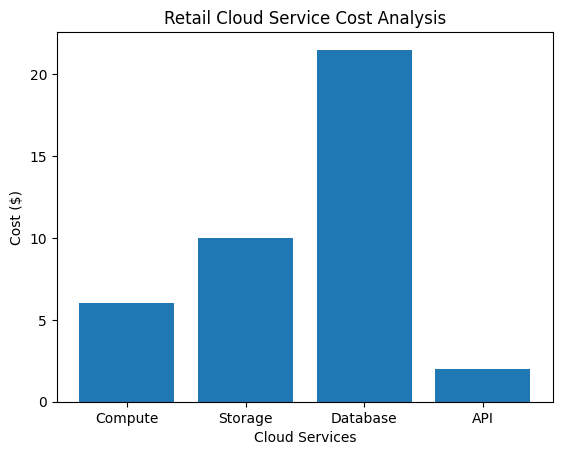

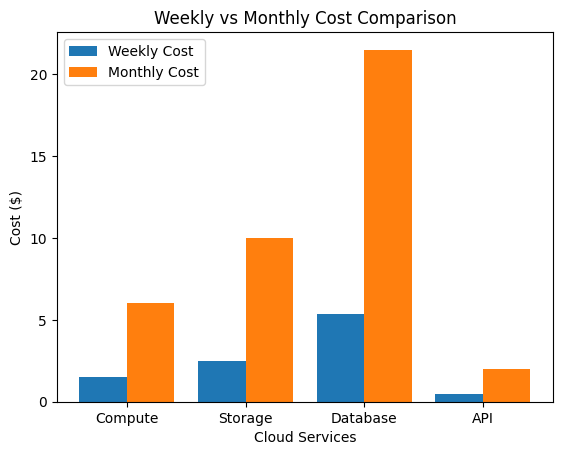


✅ Results saved to cloud_cost_result.xlsx


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data
df = pd.read_excel("cloud_usage_sample.xlsx")

# Cost Calculations
df["Compute_Cost"] = df["Usage_Hours"] * df["Price_per_Hour"]
df["Storage_Cost"] = df["Storage_GB"] * df["Price_per_GB"]
df["Request_Cost"] = df["Requests"] * df["Price_per_Request"]

df["Total_Cost"] = df["Compute_Cost"] + df["Storage_Cost"] + df["Request_Cost"]

# Total Cost
total_cost = df["Total_Cost"].sum()
print("Total Retail Cloud Cost: $", total_cost)

# Average Cost
average_cost = df["Total_Cost"].mean()
print(f"Average Cost per Service: ${average_cost:.2f}")

# ===============================
# ✅ Weekly & Monthly Estimation
# ===============================

# Assuming given data is monthly → derive weekly
df["Weekly_Cost"] = df["Total_Cost"] / 4

# Monthly cost (already total, but keeping for clarity)
df["Monthly_Cost"] = df["Total_Cost"]

# Display
print("\nWeekly vs Monthly Cost:\n")
print(df[["Service", "Weekly_Cost", "Monthly_Cost"]])

# ===============================
# 📊 Visualization 1: Total Cost
# ===============================

plt.figure()
plt.bar(df["Service"], df["Total_Cost"])
plt.xlabel("Cloud Services")
plt.ylabel("Cost ($)")
plt.title("Retail Cloud Service Cost Analysis")
plt.show()

# ===============================
# 📊 Visualization 2: Weekly vs Monthly Comparison
# ===============================

x = range(len(df["Service"]))

plt.figure()

plt.bar(x, df["Weekly_Cost"], width=0.4, label="Weekly Cost")
plt.bar([i + 0.4 for i in x], df["Monthly_Cost"], width=0.4, label="Monthly Cost")

plt.xticks([i + 0.2 for i in x], df["Service"])
plt.xlabel("Cloud Services")
plt.ylabel("Cost ($)")
plt.title("Weekly vs Monthly Cost Comparison")
plt.legend()

plt.show()

# Sort Data
df = df.sort_values("Total_Cost", ascending=False)

# Export Result
df.to_excel("cloud_cost_result.xlsx", index=False)

print("\n✅ Results saved to cloud_cost_result.xlsx")


In [2]:
df

,Service,Usage_Hours,Storage_GB,Requests,Price_per_Hour,Price_per_GB,Price_per_Request,Compute_Cost,Storage_Cost,Request_Cost,Total_Cost,Weekly_Cost,Monthly_Cost
2,Database,200,50,0,0.10,0.03,0.0000,20.0,1.5,0.0,21.5,5.375,21.5
1,Storage,0,500,0,0.00,0.02,0.0000,0.0,10.0,0.0,10.0,2.500,10.0
0,Compute,120,0,0,0.05,0.00,0.0000,6.0,0.0,0.0,6.0,1.500,6.0
3,API,0,0,20000,0.00,0.00,0.0001,0.0,0.0,2.0,2.0,0.500,2.0
